# DualPath-MedAI

---
## Link utili DataSet

1. [Link Dataset Mechanisms of Action (MoA) Prediction](https://www.kaggle.com/c/lish-moa/data)
2. [Link Dataset Drugs, Side_Effects & Medical_Conditions](https://www.kaggle.com/datasets/nailasrivastava/drugs-side-effects-and-medical-conditions)

---

## 🧬 Documentazione Dataset: Mechanisms of Action (MoA)

Il dataset MoA è strutturato in due matrici principali: le **features** (dati di input) e i **targets** (output da predire). Essendo dati anonimizzati, la seguente mappatura è fondamentale per le fasi di preprocessing e feature engineering.

### 1. File: `train_features.csv` (Variabili Indipendenti)
Questa matrice contiene i parametri del test e le misurazioni biologiche su cui il modello neurale cercherà i pattern.

* **`sig_id`**: Identificativo univoco del campione testato.
* **`cp_type`**: Tipo di trattamento.
    * `trt_cp`: Farmaco reale.
    * `ctl_vehicle`: Sostanza di controllo neutra (solvente). *Nota: queste righe vanno rimosse durante il cleaning poiché non attivano alcun meccanismo d'azione.*
* **`cp_time`**: Durata dell'esposizione al trattamento in ore (valori possibili: 24, 48, 72).
* **`cp_dose`**: Dosaggio somministrato (basso = `D1`, alto = `D2`).
* **`g-[0-771]`**: 772 feature continue. Misurano l'**espressione genica** (come hanno reagito i geni al farmaco).
* **`c-[0-99]`**: 100 feature continue. Misurano la **vitalità cellulare** (percentuale di cellule sopravvissute).

---

### 2. File: `train_targets_scored.csv` (Variabili Dipendenti)
Queste sono le etichette di ground truth per l'addestramento supervisionato.

* **`sig_id`**: Chiave primaria per il join con le features.
* **206 Colonne Target**: Ognuna rappresenta un distinto Meccanismo d'Azione biologico. I valori sono strettamente binari:
    * `1`: Il farmaco ha attivato il meccanismo.
    * `0`: Nessuna attivazione.
---

---
## Iniziamo
- carichiamo i file principali con Pandas e verifichiamo la corretta lettura
---

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# 1. Carichiamo i file principali di training
moa_train = pd.read_csv('data/moa/train_features.csv')
targets = pd.read_csv('data/moa/train_targets_scored.csv')

# (Sostituisci il nome del file clinico se diverso da quello estratto)
clinical_data = pd.read_csv('data/clinical/drugs_side_effects_drugs_com.csv')

# 2. Stampiamo le dimensioni (righe, colonne)
print(f"Dimensioni MoA (Features): {moa_train.shape}")
print(f"Dimensioni MoA (Target): {targets.shape}")
print(f"Dimensioni Dati Clinici: {clinical_data.shape}")
print("\n", "*" * 50)

# 3. Guardiamo le prime 3 righe per capire la struttura
display(moa_train.head(3))

Dimensioni MoA (Features): (23814, 876)
Dimensioni MoA (Target): (23814, 207)
Dimensioni Dati Clinici: (2966, 135)

 **************************************************


,sig_id,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
0,id_000644bb2,trt_cp,24,D1,1.0620,0.5577,-0.2479,-0.6208,-0.1944,-1.0120,...,0.2862,0.2584,0.8076,0.5523,-0.1912,0.6584,-0.3981,0.2139,0.3801,0.4176
1,id_000779bfc,trt_cp,72,D1,0.0743,0.4087,0.2991,0.0604,1.0190,0.5207,...,-0.4265,0.7543,0.4708,0.0230,0.2957,0.4899,0.1522,0.1241,0.6077,0.7371
2,id_000a6266a,trt_cp,48,D1,0.6280,0.5817,1.5540,-0.0764,-0.0323,1.2390,...,-0.7250,-0.6297,0.6103,0.0223,-1.3240,-0.3174,-0.6417,-0.2187,-1.4080,0.6931


In [27]:
# Controlliamo tramite info e describe
print("Moa Dataset:\n")
moa_train.info()
print("\n", "*" * 50)
display(moa_train.describe())
print("\n", "*" * 50)

# Controllo valori nulli e tipi di dato nel dataset clinico
print("Valori mancanti per colonna nel dataset clinico:")
display(clinical_data.isnull().sum())
print("\n", "*" * 50)

print("\nTipi di dato:")
display(clinical_data.dtypes)
print("\n", "*" * 50)

Moa Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23814 entries, 0 to 23813
Columns: 876 entries, sig_id to c-99
dtypes: float64(872), int64(1), object(3)
memory usage: 159.2+ MB

 **************************************************


,cp_time,g-0,g-1,g-2,g-3,g-4,g-5,g-6,g-7,g-8,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
count,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,...,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000,23814.000000
mean,48.020156,0.248366,-0.095684,0.152253,0.081971,0.057347,-0.138836,0.035961,-0.202651,-0.190083,...,-0.469244,-0.461411,-0.513256,-0.500142,-0.507093,-0.353726,-0.463485,-0.378241,-0.470252,-0.301505
std,19.402807,1.393399,0.812363,1.035731,0.950012,1.032091,1.179388,0.882395,1.125494,1.749885,...,2.000488,2.042475,2.001714,2.107105,2.159589,1.629291,2.059725,1.703615,1.834828,1.407918
min,24.000000,-5.513000,-5.737000,-9.104000,-5.998000,-6.369000,-10.000000,-10.000000,-10.000000,-10.000000,...,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000
25%,24.000000,-0.473075,-0.562200,-0.437750,-0.429575,-0.470925,-0.602225,-0.493900,-0.525175,-0.511675,...,-0.566175,-0.565975,-0.589975,-0.568700,-0.563775,-0.567975,-0.552575,-0.561000,-0.592600,-0.562900
50%,48.000000,-0.008850,-0.046600,0.075200,0.008050,-0.026900,-0.015650,-0.000650,-0.017900,0.010000,...,-0.009900,0.003250,-0.009100,-0.013750,-0.003300,-0.010250,-0.001250,-0.006800,0.014000,-0.019500
75%,72.000000,0.525700,0.403075,0.663925,0.463400,0.465375,0.510425,0.528725,0.411900,0.549225,...,0.457750,0.461500,0.445675,0.452900,0.470900,0.444750,0.465225,0.446400,0.461275,0.438650
max,72.000000,10.000000,5.039000,8.257000,10.000000,10.000000,7.282000,7.333000,5.473000,8.887000,...,4.069000,3.960000,3.927000,3.596000,3.747000,2.814000,3.505000,2.924000,3.111000,3.805000



 **************************************************
Valori mancanti per colonna nel dataset clinico:


drug_name               1
medical_condition       0
side_effects          124
generic_name           44
drug_classes           83
                     ... 
Unnamed: 130         2965
Unnamed: 131         2966
Unnamed: 132         2966
Unnamed: 133         2965
Unnamed: 134         2965
Length: 135, dtype: int64


 **************************************************

Tipi di dato:


drug_name             object
medical_condition     object
side_effects          object
generic_name          object
drug_classes          object
                      ...   
Unnamed: 130          object
Unnamed: 131         float64
Unnamed: 132         float64
Unnamed: 133          object
Unnamed: 134          object
Length: 135, dtype: object


 **************************************************


---
### Cerchiamo sig_id
---

In [28]:
#sig_id search
display(moa_train.head(3))
print("\n", "*" * 50)

,sig_id,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
0,id_000644bb2,trt_cp,24,D1,1.0620,0.5577,-0.2479,-0.6208,-0.1944,-1.0120,...,0.2862,0.2584,0.8076,0.5523,-0.1912,0.6584,-0.3981,0.2139,0.3801,0.4176
1,id_000779bfc,trt_cp,72,D1,0.0743,0.4087,0.2991,0.0604,1.0190,0.5207,...,-0.4265,0.7543,0.4708,0.0230,0.2957,0.4899,0.1522,0.1241,0.6077,0.7371
2,id_000a6266a,trt_cp,48,D1,0.6280,0.5817,1.5540,-0.0764,-0.0323,1.2390,...,-0.7250,-0.6297,0.6103,0.0223,-1.3240,-0.3174,-0.6417,-0.2187,-1.4080,0.6931



 **************************************************


---
### Creiamo delle liste per isolare le features per tipologia
---

In [29]:
# Creiamo delle liste per isolare le features per tipologia
gene_features = [col for col in moa_train.columns if col.startswith('g-')]
cell_features = [col for col in moa_train.columns if col.startswith('c-')]
cat_features = ['cp_type', 'cp_time', 'cp_dose']

display(f"Totale feature Geniche (g-): {len(gene_features)}")
display(f"Totale feature Cellulari (c-): {len(cell_features)}")
print("\n--- Valori Categorici ---")
display(f"Tipi di trattamento (cp_type): {moa_train['cp_type'].unique()}")
display(f"Tempi di esposizione (cp_time): {moa_train['cp_time'].unique()}")
display(f"Dosaggi (cp_dose): {moa_train['cp_dose'].unique()}")
print("\n", "*" * 50)

'Totale feature Geniche (g-): 772'

'Totale feature Cellulari (c-): 100'


--- Valori Categorici ---


"Tipi di trattamento (cp_type): ['trt_cp' 'ctl_vehicle']"

'Tempi di esposizione (cp_time): [24 72 48]'

"Dosaggi (cp_dose): ['D1' 'D2']"


 **************************************************


---
### Ipotetica normalizzazione
- filtraggio cp_type == ctl
_vehicole
---

In [30]:
# filtriamo cp_type
print('Shape prima del filtro:',moa_train.shape)

moa_train = moa_train[moa_train['cp_type'] == 'trt_cp']

print('Shape dopo il filtro:',moa_train.shape)
print("Valori cp_type dopo il filtro:", moa_train['cp_type'].unique())
print(f"Tempi di esposizione (cp_time): {moa_train['cp_time'].unique()}")
print("\n", "*" * 50)

Shape prima del filtro: (23814, 876)
Shape dopo il filtro: (21948, 876)
Valori cp_type dopo il filtro: ['trt_cp']
Tempi di esposizione (cp_time): [24 72 48]

 **************************************************


---
- drop della colonna dopo il filtraggio perché adesso sappiamo che ormai sono tutti `cp_type == 'trt_cp'`
---

In [31]:
# droppiamo la colonna
moa_train = moa_train.drop(columns=['cp_type'])
display(moa_train.head(3))
print("\n", "*" * 50)
display(moa_train.info())
print("\n", "*" * 50)
display(moa_train.dtypes)
print("\n", "*" * 50)

,sig_id,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,g-6,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
0,id_000644bb2,24,D1,1.0620,0.5577,-0.2479,-0.6208,-0.1944,-1.0120,-1.0220,...,0.2862,0.2584,0.8076,0.5523,-0.1912,0.6584,-0.3981,0.2139,0.3801,0.4176
1,id_000779bfc,72,D1,0.0743,0.4087,0.2991,0.0604,1.0190,0.5207,0.2341,...,-0.4265,0.7543,0.4708,0.0230,0.2957,0.4899,0.1522,0.1241,0.6077,0.7371
2,id_000a6266a,48,D1,0.6280,0.5817,1.5540,-0.0764,-0.0323,1.2390,0.1715,...,-0.7250,-0.6297,0.6103,0.0223,-1.3240,-0.3174,-0.6417,-0.2187,-1.4080,0.6931



 **************************************************
<class 'pandas.core.frame.DataFrame'>
Index: 21948 entries, 0 to 23813
Columns: 875 entries, sig_id to c-99
dtypes: float64(872), int64(1), object(2)
memory usage: 146.7+ MB


None


 **************************************************


sig_id      object
cp_time      int64
cp_dose     object
g-0        float64
g-1        float64
            ...   
c-95       float64
c-96       float64
c-97       float64
c-98       float64
c-99       float64
Length: 875, dtype: object


 **************************************************


---
### Merge del dataframe targets
---

In [32]:
#join tra i dui dataframe per escludere gli stessi record di cp_type
targets = targets[targets['sig_id'].isin(moa_train['sig_id'])]

# controllo per il check di confronto
display(moa_train.shape, targets.shape)
print("\n", "*" * 50)

# merge
data = moa_train.merge(targets, on='sig_id')

# lettura di data
display(data.shape)
print("\n", "*" * 50)

(21948, 875)

(21948, 207)


 **************************************************


(21948, 1081)


 **************************************************


---
### Plot e controllo visivo per controllo della distribuzione quindi standardizzazione
- g-0 g-1
- c-0 c-1
---

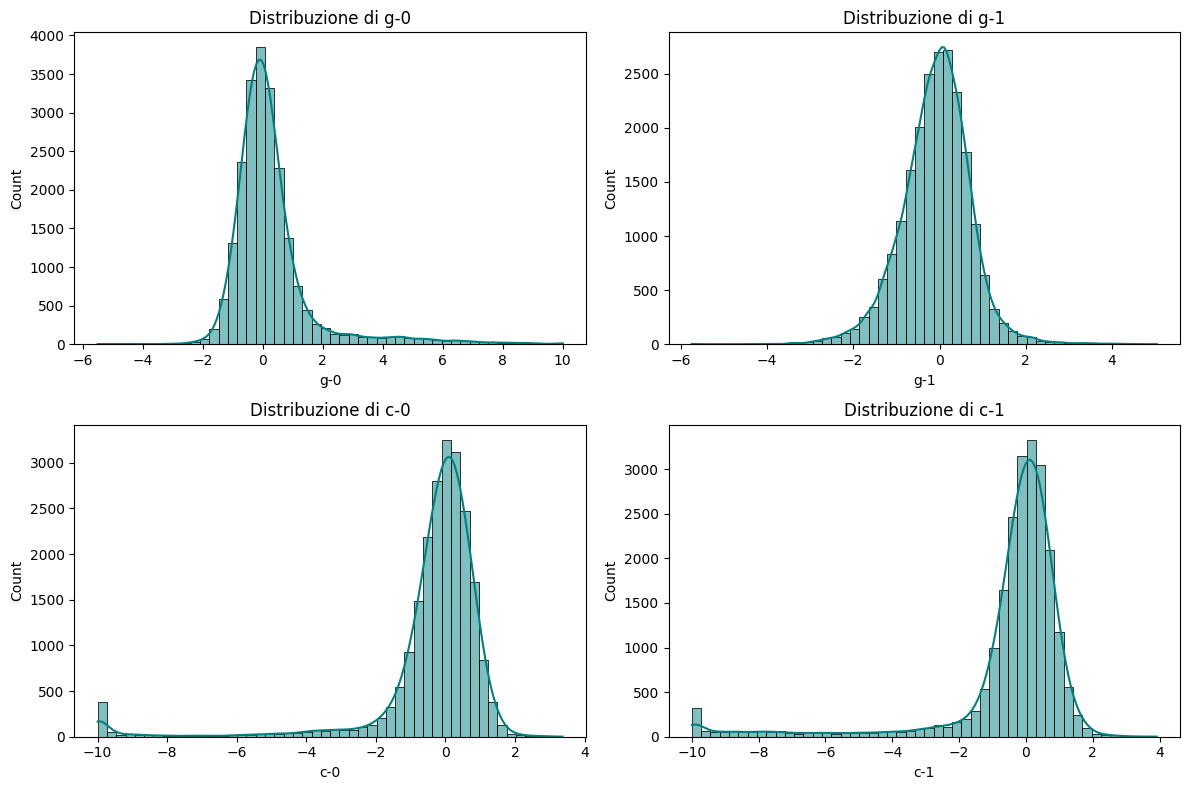

In [33]:
# Selezioniamo 2 feature geniche e 2 cellulari a caso per il plot
features_to_plot = ['g-0', 'g-1', 'c-0', 'c-1']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    # Usiamo seaborn per un istogramma con la curva di densità (KDE)
    sns.histplot(data[col], bins=50, kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribuzione di {col}')

plt.tight_layout()
plt.show()

---
### Trasformazione in numeri `cp_dose` e `cp_time`

1. `cp_dose`: è binaria (D1, D2). La mappiamo in 0 e 1.
  - `D1 = 0`: dose bassa
  - `D2 = 1`: dose alta
2. `cp_time`: contiene ore (24, 48, 72). Possiamo semplicemente dividerla per 72 per scalarla proporzionalmente tra 0 e 1
---

In [34]:
# 1. Mappatura binaria per la dose
data['cp_dose'] = data['cp_dose'].map({'D1': 0, 'D2': 1})

# 2. Scaliamo il tempo di esposizione tra 0 e 1
data['cp_time'] = data['cp_time'] / 72.0

# Check visivo del risultato
display(data[['cp_time', 'cp_dose']].head())

,cp_time,cp_dose
0,0.333333,0
1,1.000000,0
2,0.666667,0
3,0.666667,0
4,1.000000,1


---
### Controllo valori nulli e set `sig_id` come id del dataset
---

In [35]:
# 1. Controllo finale e assoluto sui valori mancanti
print(f"Totale valori nulli nel dataset MoA unito: {data.isnull().sum().sum()}")

# 2. Spostiamo sig_id come indice del DataFrame
data = data.set_index('sig_id')

# Verifica finale della struttura
display(data.head(3))

Totale valori nulli nel dataset MoA unito: 0


,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,g-6,g-7,...,tropomyosin_receptor_kinase_inhibitor,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor
sig_id,,,,,,,,,,,,,,,,,,,,,
id_000644bb2,0.333333,0,1.0620,0.5577,-0.2479,-0.6208,-0.1944,-1.0120,-1.0220,-0.0326,...,0,0,0,0,0,0,0,0,0,0
id_000779bfc,1.000000,0,0.0743,0.4087,0.2991,0.0604,1.0190,0.5207,0.2341,0.3372,...,0,0,0,0,0,0,0,0,0,0
id_000a6266a,0.666667,0,0.6280,0.5817,1.5540,-0.0764,-0.0323,1.2390,0.1715,0.2155,...,0,0,0,0,0,0,0,0,0,0


---
## 🧠 Architettura del Modello: Separazione tra X (Features) e Y (Targets)

In ogni progetto di Machine Learning supervisionato, il dataset deve essere concettualmente e strutturalmente diviso in due matrici principali prima dell'addestramento o della selezione delle variabili:

* **X (Le Features / Input):** Rappresentano gli "indizi" o le variabili indipendenti. Nel nostro progetto MoA, queste sono l'espressione genica (`g-`), la vitalità cellulare (`c-`), il tempo di esposizione e la dose. Sono i dati puri che il modello analizzerà per scovare dei pattern.
* **Y (I Targets / Output):** Rappresentano le "soluzioni" o la variabile dipendente (ground truth). Nel nostro caso, sono le 206 colonne dei Meccanismi d'Azione. È esattamente ciò che la rete neurale deve imparare a predire.

### ⚠️ Perché applicare VarianceThreshold SOLO sulle Features (X)?
Il `VarianceThreshold` è un filtro che rimuove le colonne con una varianza vicina allo zero (ovvero dati "piatti" che non cambiano quasi mai e non offrono potere predittivo).

I nostri Target (**Y**) sono matrici sparse composte quasi interamente da zeri, poiché l'attivazione di un farmaco per un meccanismo specifico è un evento biologicamente raro. Se applicassimo il filtro sull'intero dataset unito, l'algoritmo eliminerebbe per errore le colonne dei Target scambiandole per "dati inutili", distruggendo l'obiettivo del progetto.

**Regola d'oro:** Le tecniche di riduzione della dimensionalità si applicano sempre e solo alla matrice **X**.

---

In [36]:
from sklearn.feature_selection import VarianceThreshold

# 1. Isolare X (features) e Y (targets) per non distruggere le etichette
target_cols = [col for col in targets.columns if col != 'sig_id']
feature_cols = [col for col in data.columns if col not in target_cols]

X = data[feature_cols]
Y = data[target_cols]

# Feature engineering biologico
# Calcoliamo tutto in blocco per evitare PerformanceWarning
feat_engineered = pd.DataFrame({
    "g_mean": X[gene_features].mean(axis=1),
    "g_std": X[gene_features].std(axis=1),
    "c_mean": X[cell_features].mean(axis=1),
    "c_std": X[cell_features].std(axis=1),
})
feat_engineered["gc_ratio"] = feat_engineered["g_mean"] / (feat_engineered["c_mean"] + 1e-6)

# Unione features originali + ingegnerizzate
X_final = pd.concat([X, feat_engineered], axis=1)

print("Shape features dopo feature engineering:", X_final.shape)

# 2. Inizializzare il selettore (0.01 significa scartare feature quasi costanti al 99%)
selector = VarianceThreshold(threshold=0.01)

# 3. Fit e transform, ma ricostruiamo il DataFrame per non perdere i nomi delle colonne
X_reduced = selector.fit_transform(X)
X_reduced_df = pd.DataFrame(X_reduced,
                            columns=X.columns[selector.get_support()],
                            index=X.index)

print(f"Features originali: {X.shape[1]}")
print(f"Features mantenute: {X_reduced_df.shape[1]}")
print(f"Features scartate per bassa varianza: {X.shape[1] - X_reduced_df.shape[1]}")

# 4. Ricongiungiamo X pulita e Y per il salvataggio finale
final_data = pd.concat([X_reduced_df, Y], axis=1)

Shape features dopo feature engineering: (21948, 879)
Features originali: 874
Features mantenute: 874
Features scartate per bassa varianza: 0


### visualizzazione del plot

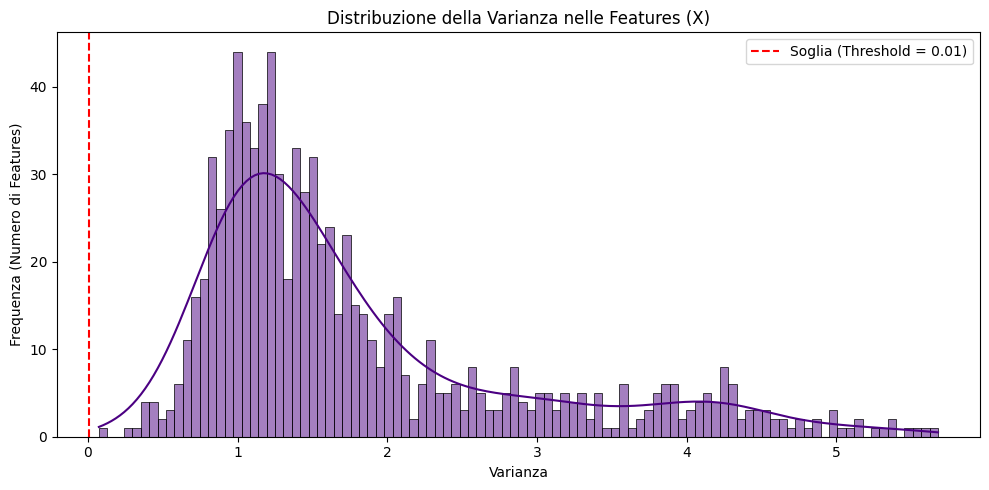

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcoliamo la varianza per ogni singola feature in X
variances = X.var()

# 2. Creiamo l'istogramma delle varianze
plt.figure(figsize=(10, 5))
sns.histplot(variances, bins=100, kde=True, color='indigo')

# 3. Tracciamo la nostra soglia di taglio (0.01)
plt.axvline(x=0.01, color='red', linestyle='--', label='Soglia (Threshold = 0.01)')

plt.title('Distribuzione della Varianza nelle Features (X)')
plt.xlabel('Varianza')
plt.ylabel('Frequenza (Numero di Features)')
plt.legend()
plt.tight_layout()
plt.show()


## Standardizzazione delle Feature (StandardScaler)

Prima di addestrare i modelli di Machine Learning è utile normalizzare le variabili.  
Nel nostro dataset le feature (espressione genica e cellulare) possono avere scale molto diverse.

Per questo utilizziamo **StandardScaler**, che trasforma ogni variabile in modo che abbia:

- media = 0
- deviazione standard = 1

La trasformazione applicata è:

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_reduced_df)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_reduced_df.columns,
    index=X_reduced_df.index
)

print("Shape dopo scaling:", X_scaled.shape)

Shape dopo scaling: (21948, 874)


## Riduzione della Dimensionalità con PCA

Il dataset contiene centinaia di feature biologiche (geni e cellule), molte delle quali sono correlate tra loro.

Per ridurre la dimensionalità e il rumore nei dati utilizziamo **Principal Component Analysis (PCA)**.

La PCA:

- combina le feature originali in nuove variabili chiamate **componenti principali**
- mantiene la maggior parte della varianza dei dati
- riduce il numero di variabili da analizzare

Nel nostro caso riduciamo le feature a **200 componenti principali**, mantenendo la maggior parte dell'informazione utile per il modello.


Shape PCA features: (21948, 200)
Shape targets: (21948, 206)


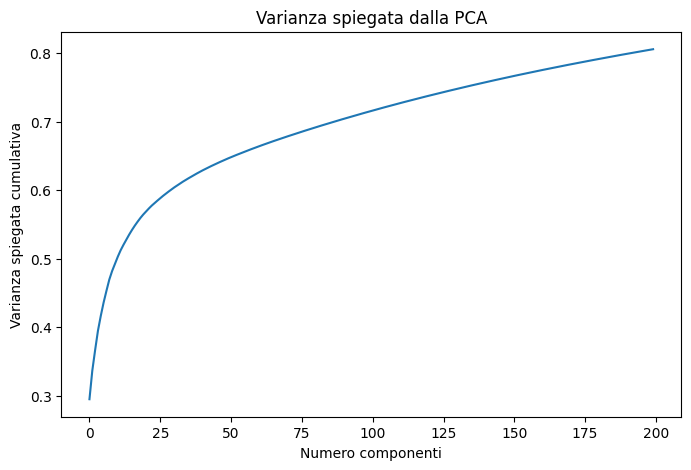

Shape dataset finale: (21948, 406)


In [39]:
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=200)
X_pca = pca.fit_transform(X_scaled)

X_pca_df = pd.DataFrame(
    X_pca,
    index=X_scaled.index
)

# nomi colonne
X_pca_df.columns = [f"PC{i}" for i in range(X_pca_df.shape[1])]

# controllo shape
print("Shape PCA features:", X_pca_df.shape)
print("Shape targets:", Y.shape)

# grafico varianza spiegata
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Numero componenti")
plt.ylabel("Varianza spiegata cumulativa")
plt.title("Varianza spiegata dalla PCA")
plt.show()

# dataset finale
final_data = pd.concat([X_pca_df, Y], axis=1)

print("Shape dataset finale:", final_data.shape)


---
#### Esportazione del DataFrame pulito e normalizzato
---


In [40]:
# Esportazione del DataFrame pulito e normalizzato
final_data.to_csv('data/new_data/moa/moa_ready.csv', index=False)
print("Dataset MoA pronto e salvato in: data/new_data/moa/moa_ready.csv")

Dataset MoA pronto e salvato in: data/new_data/moa/moa_ready.csv


### Dobbiamo costruire una rete neurale in grado di prevedere non una, ma ben 206 probabilità diverse contemporaneamente.

Il primissimo passo è ricaricare il nostro dataset definitivo e preparare i tensori per Keras, dividendo i dati in un set di addestramento e uno di validazione.

In [41]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import json

# 1. Carichiamo il dataset pulito
data = pd.read_csv('data/new_data/moa/moa_ready.csv')

# 1. Feature (tutte tranne le ultime 206)
feature_cols = data.iloc[:, :-206].columns.tolist()
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

# 2. Target (le ultime 206)
target_labels = data.iloc[:, -206:].columns.tolist()
with open('target_labels.json', 'w') as f:
    json.dump(target_labels, f)

print(f"JSON Generati! Features: {len(feature_cols)} | Targets: {len(target_labels)}")

# 2. Separiamo X e Y (sappiamo che i target sono le ultime 206 colonne)
X = data.iloc[:, :-206].values
Y = data.iloc[:, -206:].values

# 3. Divisione in Train e Validation set (80% training, 20% test interno)
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training Features (X_train): {X_train.shape}")
print(f"Training Targets (Y_train): {Y_train.shape}")

print("\n", "*" * 50)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Shape delle Features (X): {X.shape}")
print(f"Shape dei Target (Y): {Y.shape}")

JSON Generati! Features: 200 | Targets: 206
Training Features (X_train): (17558, 200)
Training Targets (Y_train): (17558, 206)

 **************************************************
TensorFlow Version: 2.20.0
Shape delle Features (X): (21948, 200)
Shape dei Target (Y): (21948, 206)


## 🔗 Integrazione Dati: Il Ponte verso i Farmaci (train_drug.csv)

Il file `train_drug.csv` contiene la mappatura tra gli esperimenti e le molecole.
Carichiamo questo dataset per esaminare come associare i nostri dati attuali (`sig_id`) ai farmaci (`drug_id`). Questa operazione è propedeutica per il successivo *merge* con i dati clinici avanzati.

In [42]:
# 1. Carichiamo la mappatura dei farmaci di Kaggle
drugs_moa = pd.read_csv('data/moa/train_drug.csv')

# 2. Stampiamo le info essenziali
print(f"Dimensioni mappatura farmaci: {drugs_moa.shape}")
print(f"Numero di farmaci unici: {drugs_moa['drug_id'].nunique()}")
display(drugs_moa.head())

Dimensioni mappatura farmaci: (23814, 2)
Numero di farmaci unici: 3289


,sig_id,drug_id
0,id_000644bb2,b68db1d53
1,id_000779bfc,df89a8e5a
2,id_000a6266a,18bb41b2c
3,id_0015fd391,8c7f86626
4,id_001626bd3,7cbed3131


## 🧬 Data Merging: Associazione Esperimenti-Farmaci

Eseguiamo una `Left Join` per unire le feature di addestramento (`train_features.csv`) con i codici dei farmaci (`train_drug.csv`). 
La chiave di unione è `sig_id` (l'identificativo univoco dell'esperimento). Questo passaggio è fondamentale per raggruppare le reazioni biologiche per singola molecola prima di introdurre il dataset clinico.

In [43]:
# 1. Ricarichiamo le features originali di training
train_features = pd.read_csv('data/moa/train_features.csv')

# 2. Eseguiamo il merge (Left Join) basato sulla colonna 'sig_id'
train_features_with_drugs = pd.merge(train_features, drugs_moa, on='sig_id', how='left')

# 3. Verifica strutturale
print(f"Dimensioni features originali: {train_features.shape}")
print(f"Dimensioni dopo il merge: {train_features_with_drugs.shape}")
display(train_features_with_drugs[['sig_id', 'drug_id']].head())

Dimensioni features originali: (23814, 876)
Dimensioni dopo il merge: (23814, 877)


,sig_id,drug_id
0,id_000644bb2,b68db1d53
1,id_000779bfc,df89a8e5a
2,id_000a6266a,18bb41b2c
3,id_0015fd391,8c7f86626
4,id_001626bd3,7cbed3131


### Addestramento

In [44]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Definizione dell'architettura Multi-Label
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    
    # Primo Hidden Layer
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Secondo Hidden Layer
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Output Layer (206 nodi, attivazione sigmoid per output indipendenti)
    layers.Dense(206, activation='sigmoid') 
])

# Compilazione del modello
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['AUC'])

# Stampa l'architettura per verifica
model.summary()

from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop]
)

# Valutazione sul validation set
val_loss, val_auc = model.evaluate(X_val, Y_val)

print("Validation Loss:", val_loss)
print("Validation AUC:", val_auc)

# Salva il modello
model.save("moa_nn_model.h5")

# Salva scaler e PCA
import joblib
joblib.dump(scaler, "moa_scaler.pkl")
joblib.dump(pca, "moa_pca.pkl")

print("Modello, scaler e PCA salvati!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │       102,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 206)            │        52,942 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,254 (1.11 MB)

 Trainable params: 288,718 (1.10 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/50


2026-03-10 12:16:54.174957: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28935584 exceeds 10% of free system memory.


138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.5615 - loss: 0.4844 - val_AUC: 0.6579 - val_loss: 0.0859
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6170 - loss: 0.0472 - val_AUC: 0.7407 - val_loss: 0.0270
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7023 - loss: 0.0254 - val_AUC: 0.7691 - val_loss: 0.0218
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7438 - loss: 0.0222 - val_AUC: 0.7716 - val_loss: 0.0206
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7565 - loss: 0.0209 - val_AUC: 0.7688 - val_loss: 0.0197
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7646 - loss: 0.0204 - val_AUC: 0.7759 - val_loss: 0.0193
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7681 - loss: 0.0197 - val_AUC: 0.7736 - val_loss: 0.0187
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7755 - loss: 0.0191 - val_AUC: 0.7777 - val_loss: 0.0184
Epoch 9/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.7820 -

Validation Loss: 0.016978196799755096
Validation AUC: 0.8052445650100708
Modello, scaler e PCA salvati!


## Training LightGBM model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import joblib

# 1. Carica i modelli LightGBM salvati
estimators = joblib.load('lgb_206_models.pkl')
print(f"Caricati {len(estimators)} modelli LightGBM.")

# 2. Ricostruisci X_val come DataFrame con le colonne corrette
# Usa le colonne con cui sono stati addestrati i modelli (qui assumo X_pca_df)
X_val_df = pd.DataFrame(X_val, columns=X_pca_df.columns)

# 3. Array per salvare le predizioni
Y_pred = np.zeros_like(Y_val, dtype=float)

# 4. Predizione per ciascun modello
for i, clf in enumerate(estimators):
    # predict_proba restituisce due colonne: [classe 0, classe 1]
    # prendiamo solo la probabilità della classe positiva
    Y_pred[:, i] = clf.predict_proba(X_val_df)[:, 1]

# 5. Calcolo AUC per ciascun target
auc_list = []

for i in range(Y_val.shape[1]):
    # Verifica che ci siano almeno due classi nel target
    if len(np.unique(Y_val[:, i])) > 1:
        auc = roc_auc_score(Y_val[:, i], Y_pred[:, i])
        auc_list.append(auc)
    else:
        # Target raro, AUC non definita
        auc_list.append(np.nan)

# 6. AUC medio ignorando NaN
mean_auc = np.nanmean(auc_list)

print(f"AUC medio LightGBM (solo target validi): {mean_auc:.4f}")
print(f"Numero di target considerati: {np.sum(~np.isnan(auc_list))}/{Y_val.shape[1]}")

FileNotFoundError: [Errno 2] No such file or directory: 'lgb_206_models.pkl'

## Training XGBoost model

In [ ]:
import xgboost as xgb
import numpy as np
import joblib
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

print("\nTraining XGBoost models...")

xgb_models = []

# Ricostruiamo X_train come DataFrame con nomi delle colonne
X_train_df = pd.DataFrame(X_train, columns=X_pca_df.columns)
X_val_df = pd.DataFrame(X_val, columns=X_pca_df.columns)

# Loop sui 206 target
for i in tqdm(range(Y_train.shape[1])):

    model = xgb.XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        n_jobs=-1
    )

    model.fit(
        X_train_df,
        Y_train[:, i],
        eval_set=[(X_val_df, Y_val[:, i])],
        verbose=False
    )

    xgb_models.append(model)

print(f"\nAddestrati {len(xgb_models)} modelli XGBoost!")

# Salvataggio modelli
joblib.dump(xgb_models, "xgb_206_models.pkl")

print("Modelli XGBoost salvati!")


Training XGBoost models...


  6%|▌         | 12/206 [02:28<41:25, 12.81s/it]/home/ovrtnkdev/.local/lib/python3.12/site-packages/xgboost/callback.py:265: UserWarning: [12:20:07] WARNING: /__w/xgboost/xgboost/src/metric/auc.cc:324: Dataset is empty, or contains only positive or negative samples.
  score: str = model.eval_set(evals, epoch, self.metric, self._output_margin)
/home/ovrtnkdev/.local/lib/python3.12/site-packages/xgboost/callback.py:265: UserWarning: [12:20:08] WARNING: /__w/xgboost/xgboost/src/metric/auc.cc:324: Dataset is empty, or contains only positive or negative samples.
  score: str = model.eval_set(evals, epoch, self.metric, self._output_margin)
/home/ovrtnkdev/.local/lib/python3.12/site-packages/xgboost/callback.py:265: UserWarning: [12:20:09] WARNING: /__w/xgboost/xgboost/src/metric/auc.cc:324: Dataset is empty, or contains only positive or negative samples.
  score: str = model.eval_set(evals, epoch, self.metric, self._output_margin)
/home/ovrtnkdev/.local/lib/python3.12/site-packages/xgboost/c

## Valutazione del modello XGBoost

In [ ]:
import numpy as np

# Array predizioni
Y_pred = np.zeros_like(Y_val, dtype=float)

for i, model in enumerate(xgb_models):
    Y_pred[:, i] = model.predict_proba(X_val_df)[:, 1]

# Calcolo AUC per ogni target
auc_list = []

for i in range(Y_val.shape[1]):

    if len(np.unique(Y_val[:, i])) > 1:
        auc = roc_auc_score(Y_val[:, i], Y_pred[:, i])
        auc_list.append(auc)
    else:
        auc_list.append(np.nan)

mean_auc = np.nanmean(auc_list)

print(f"AUC medio XGBoost: {mean_auc:.4f}")
print(f"Target valutati: {np.sum(~np.isnan(auc_list))}/{Y_val.shape[1]}")

## Front-end

In [ ]:
import json

# Sostituisci 'data' con il nome del tuo DataFrame originale
# Selezioniamo solo le colonne di input (escludendo i target)
feature_names = data.iloc[:, :-206].columns.tolist() 

with open('feature_cols.json', 'w') as f:
    json.dump(feature_names, f)

print(f"Salvate {len(feature_names)} feature in 'feature_cols.json'")

In [ ]:
import json

# Prendiamo i nomi delle 206 colonne dei target (MoA)
# Assicurati di usare il DataFrame dei target originale (es. y_train_df o train_targets)
# Qui assumo che le ultime 206 colonne del tuo dataset originale siano i target
target_names = targets.columns.tolist() # Se il tuo DF si chiama train_targets
if 'sig_id' in target_names: target_names.remove('sig_id') # Pulizia se necessario

with open('target_labels.json', 'w') as f:
    json.dump(target_names, f)

print(f"Legenda MoA salvata! Creato file con {len(target_names)} etichette.")

## Rete 2: Medical & Side Effects

In [ ]:
import pandas as pd

# Percorsi dei file
path_cleaned = 'data/clinical/drugs_cleaned_dataset.xls'
path_side_effects = 'data/clinical/drugs_side_effects_drugs_com.csv'

# 1. Caricamento Side Effects (CSV standard)
df_side_effects = pd.read_csv(path_side_effects)

# 2. Caricamento Cleaned Dataset (Tentativo automatico)
try:
    # Tentativo 1: È un TSV mascherato da Excel
    df_cleaned = pd.read_csv(path_cleaned, sep='\t')
    print("drugs_cleaned_dataset caricato come file di testo!")
except Exception:
    # Tentativo 2: È un vero vecchio Excel (se ti dà errore qui, apri il terminale e fai 'pip install xlrd')
    df_cleaned = pd.read_excel(path_cleaned, engine='xlrd')
    print("drugs_cleaned_dataset caricato come vero Excel!")

# --- ESPLORAZIONE ---
print("\n--- DRUGS CLEANED INFO ---")
print(df_cleaned.info())

print("\n--- SIDE EFFECTS INFO ---")
print(df_side_effects.info())

display(df_side_effects.head(3))

## 🏥 Rete 2: Medical & Side Effects (NLP Pathway)
In questa sezione costruiamo il secondo pilastro dell'architettura **DualPath-MedAI**. 
Affrontiamo un problema di **Multi-Label Classification** con dataset ad alta dimensionalità testuale:
1. **Feature Engineering (X):** Utilizzo di `TfidfVectorizer` per trasformare le condizioni mediche e le classi dei farmaci in vettori numerici (NLP).
2. **Target Encoding (Y):** Utilizzo di `MultiLabelBinarizer` per mappare gli effetti collaterali multipli in una matrice sparsa binaria.
3. **Modello Deep Learning:** Rete fully-connected con output `Sigmoid` e loss `binary_crossentropy` per calcolare probabilità indipendenti su 1827 possibili effetti avversi.

### Estrazione dei Target (Y)
Serve a "smontare" le frasi degli effetti collaterali, pulirle e creare la matrice degli output per la rete:

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import re

# Lavoriamo sul dataset pulito
df = df_cleaned.copy()

# Funzione per pulire il testo e creare liste di effetti singoli
def extract_effects(text):
    if type(text) != str:
        return []
    # Mettiamo in minuscolo, togliamo parentesi e dividiamo per virgola o punto e virgola
    text = re.sub(r'[()]', '', text.lower())
    effects = [e.strip() for e in re.split(r'[,;]', text) if e.strip()]
    return effects

# Applichiamo la funzione
df['side_effects_list'] = df['side_effects'].apply(extract_effects)

# Trasformiamo le liste in una matrice di 0 e 1 (One-Hot Encoding per target multipli)
mlb = MultiLabelBinarizer()
Y_medical = mlb.fit_transform(df['side_effects_list'])

print(f"Matrice Target (Y) creata! Shape: {Y_medical.shape}")
print(f"Numero totale di effetti collaterali unici: {len(mlb.classes_)}")
print("\nEsempio dei primi 10 effetti categorizzati:")
print(mlb.classes_[:10])

### Vettorizzazione Input e Creazione Modello

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

# 1. Uniamo le informazioni chiave in un'unica stringa per ogni farmaco
df['features_text'] = df['medical_condition'].astype(str) + " " + df['drug_classes'].astype(str)

# 2. Trasformiamo il testo in numeri con TF-IDF
tfidf = TfidfVectorizer(max_features=500) # Limitiamo a 500 parole chiave per non appesantire
X_medical = tfidf.fit_transform(df['features_text']).toarray()

print(f"Matrice Input (X) creata! Shape: {X_medical.shape}")

# 3. Divisione Train/Test
X_train_m, X_test_m, Y_train_m, Y_test_m = train_test_split(X_medical, Y_medical, test_size=0.2, random_state=42)

# 4. Architettura della Rete Neurale (Multi-Label)
model_medical = Sequential([
    Dense(256, activation='relu', input_shape=(X_medical.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    # L'ultimo layer DEVE avere lo stesso numero dei target (1827) e attivazione SIGMOID (non softmax)
    Dense(Y_medical.shape[1], activation='sigmoid') 
])

# Compilazione con Binary Crossentropy (fondamentale per predizioni multi-label)
model_medical.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nArchitettura Modello Medical:")
model_medical.summary()

In [ ]:
import joblib
from tensorflow.keras.callbacks import EarlyStopping

print("Avvio addestramento modello Medical...")

# Usiamo l'EarlyStopping per fermare l'addestramento se non migliora, evitando l'overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Addestramento (batch_size piccolo perché abbiamo solo 251 farmaci)
history_medical = model_medical.fit(
    X_train_m, Y_train_m,
    validation_data=(X_test_m, Y_test_m),
    epochs=40,
    batch_size=16, 
    callbacks=[early_stop],
    verbose=1
)

# --- SALVATAGGIO ASSET PER IL FRONTEND ---
model_medical.save('medical_model.h5')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(mlb, 'mlb_binarizer.pkl')

print("\nAddestramento completato!")
print("Modello (medical_model.h5) e Trasformatori NLP (.pkl) salvati correttamente.")

## Training LightGBM

In [ ]:
import lightgbm as lgb
import numpy as np
import joblib
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

print("\nTraining LightGBM models for Medical dataset...")

lgb_medical_models = []

for i in tqdm(range(Y_train_m.shape[1])):

    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1
    )

    model.fit(
        X_train_m,
        Y_train_m[:, i]
    )

    lgb_medical_models.append(model)

print(f"Addestrati {len(lgb_medical_models)} modelli LightGBM!")

# Salvataggio
joblib.dump(lgb_medical_models, "lgb_medical_models.pkl")

print("Modelli LightGBM Medical salvati!")

## Valutazione LightGBM

In [ ]:
Y_pred = np.zeros_like(Y_test_m, dtype=float)

for i, model in enumerate(lgb_medical_models):
    Y_pred[:, i] = model.predict_proba(X_test_m)[:, 1]

auc_list = []

for i in range(Y_test_m.shape[1]):

    if len(np.unique(Y_test_m[:, i])) > 1:
        auc = roc_auc_score(Y_test_m[:, i], Y_pred[:, i])
        auc_list.append(auc)
    else:
        auc_list.append(np.nan)

mean_auc = np.nanmean(auc_list)

print(f"AUC medio LightGBM Medical: {mean_auc:.4f}")

## Training XGBoost

In [ ]:
import xgboost as xgb

print("\nTraining XGBoost models for Medical dataset...")

xgb_medical_models = []

for i in tqdm(range(Y_train_m.shape[1])):

    model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        tree_method='hist',
        n_jobs=-1
    )

    model.fit(
        X_train_m,
        Y_train_m[:, i]
    )

    xgb_medical_models.append(model)

print(f"Addestrati {len(xgb_medical_models)} modelli XGBoost!")

joblib.dump(xgb_medical_models, "xgb_medical_medical_models.pkl")

print("Modelli XGBoost Medical salvati!")

## Valutazione XGBoost

In [ ]:
Y_pred = np.zeros_like(Y_test_m, dtype=float)

for i, model in enumerate(xgb_medical_models):
    Y_pred[:, i] = model.predict_proba(X_test_m)[:, 1]

auc_list = []

for i in range(Y_test_m.shape[1]):

    if len(np.unique(Y_test_m[:, i])) > 1:
        auc = roc_auc_score(Y_test_m[:, i], Y_pred[:, i])
        auc_list.append(auc)
    else:
        auc_list.append(np.nan)

mean_auc = np.nanmean(auc_list)

print(f"AUC medio XGBoost Medical: {mean_auc:.4f}")